In [1]:
%env JAX_PLATFORM_NAME=cpu
%env CUDA_VISIBLE_DEVICES=2
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from isolation_forest import IsolationTree
import balif

env: JAX_PLATFORM_NAME=cpu
env: CUDA_VISIBLE_DEVICES=2


In [2]:
n_components = 2
rng = jax.random.PRNGKey(42)
data = jax.random.normal(rng, (16, 2))
tree = IsolationTree.fit(rng, data, n_components)

path = tree.path(data[0])
print(path)
M =balif.get_score_matrix(len(path), len(data))
print((M*100).astype(int))


[0 1 3 7]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 100]
 [  0   6  13  20  26  33  40  46  53  60  66  73  80  86  93 100 100]
 [  0  28  43  55  64  72  78  84  88  92  94  96  98  99 100 100 100]
 [  0  58  73  82  88  92  95  97  98  99  99  99  99 100 100 100 100]
 [  0  82  90  95  97  98  99  99  99  99  99  99  99  99  99 100 100]]


data reached node [1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


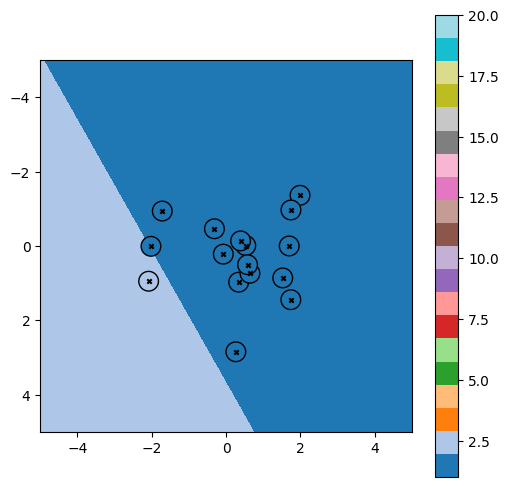

data reached node [3 5 3 4 4 3 3 3 3 4 4 4 4 4 3 3]


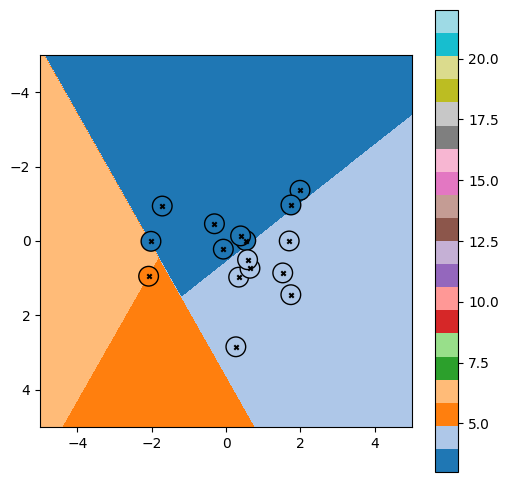

data reached node [ 7 11  7 10  9  8  7  8  7 10 10  9 10  9  7  7]


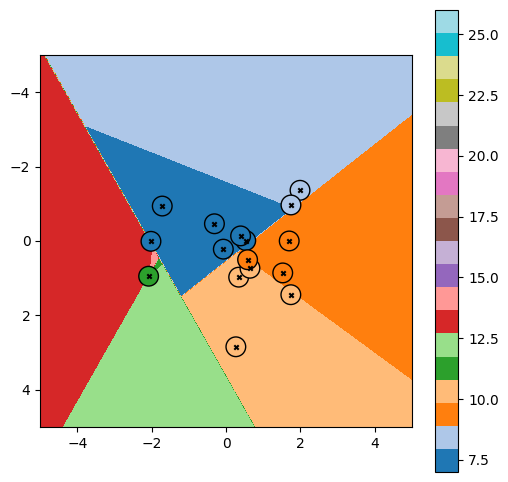

In [3]:

X, Y = jnp.meshgrid(jnp.linspace(-5, 5, 1000), jnp.linspace(-5, 5, 1000))
coord = jnp.stack([X.flatten(), Y.flatten()]).T
data_paths = jax.vmap(tree.path)(data)
region_paths = jax.vmap(tree.path)(coord)

for depth, (data_path_ids, region_paths_ids) in enumerate(
    zip(data_paths[:, 1:].T, region_paths[:, 1:].T)
):
    print(f"data reached node {data_path_ids}")
    plt.figure(figsize=(6, 6))
    # scatter data color coded by region
    plt.scatter(
        data[:, 0], data[:, 1],s=200, c=data_path_ids,cmap="tab20", edgecolors="k",
        vmin=region_paths_ids.min(), vmax=region_paths_ids.min() + 19,
    )
    plt.scatter(data[:, 0], data[:, 1], marker="x", c="k", s=10)
    # imshow node regions
    plt.imshow(
        region_paths_ids.reshape(1000, 1000), cmap="tab20", vmin=region_paths_ids.min(),
        vmax=region_paths_ids.min() + 19, extent=(-5, 5, 5, -5),
    )
    plt.colorbar()
    plt.show()